In [1]:
from pathlib import Path
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load

from dataeval_flow.preprocessing import PreprocessingStep

mnist_train = cast(Dataset, hf_load("ylecun/mnist", split="train"))
mnist_test = cast(Dataset, hf_load("ylecun/mnist", split="test"))

train_path = Path("./data/mnist/train")
test_path = Path("./data/mnist/test")
mnist_train.save_to_disk(str(train_path))
mnist_test.save_to_disk(str(test_path))

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving the dataset (0/1 shards):   0%|                                                                                                                                    | 0/60000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):  83%|████████████████████████████████████████████████████████████████████████████████████████████████▋                   | 50000/60000 [00:00<00:00, 473730.32 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60000/60000 [00:00<00:00, 473730.32 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60000/60000 [00:00<00:00, 464669.89 examples/s]

Saving the dataset (0/1 shards):   0%|                                                                                                                                    | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 463869.06 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 451865.29 examples/s]

In [2]:
import numpy as np
from PIL import Image, ImageFilter


def _corrupt_test_data(ds: Dataset) -> Dataset:
    """Return a copy of *ds* with corrupted images at indices 900-999."""
    images = list(ds["image"])  # list of PIL images

    # Exact duplicates: copy images 180-199 into slots 900-919
    for i, src in zip(range(900, 920), range(200, 220), strict=True):
        images[i] = images[src].copy()

    # Gaussian blur (indices 920-939)
    for i in range(920, 940):
        images[i] = images[i].filter(ImageFilter.GaussianBlur(radius=3))

    # Random noise (indices 940-959)
    for i in range(940, 960):
        arr = np.array(images[i], dtype=np.int16)
        noise = np.random.default_rng(i).integers(-80, 80, arr.shape, dtype=np.int16)
        images[i] = Image.fromarray(np.clip(arr + noise, 0, 255).astype(np.uint8))

    # Overexposure (indices 960-979)
    for i in range(960, 980):
        arr = np.array(images[i], dtype=np.int16)
        images[i] = Image.fromarray(np.clip(arr + 100, 0, 255).astype(np.uint8))

    # Underexposure (indices 980-999)
    for i in range(980, 1000):
        arr = np.array(images[i], dtype=np.int16)
        images[i] = Image.fromarray((np.clip(arr - 200, 0, 255) // 2).astype(np.uint8))

    return ds.select(range(len(ds))).map(
        lambda _example, idx: {"image": images[idx]},
        with_indices=True,
    )


mnist_test_corrupted = _corrupt_test_data(mnist_test)

# Overwrite the saved test split with the corrupted version
mnist_test_corrupted.save_to_disk(str(test_path))
print(
    "Test data corrupted: 20 exact duplicates (900-919), "
    "20 blurred (920-939), 20 noisy (940-959), "
    "20 bright (960-979), 20 dark (980-999)"
)

Saving the dataset (0/1 shards):   0%|                                                                                                                                    | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 434823.14 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 418180.04 examples/s]

Test data corrupted: 20 exact duplicates (900-919), 20 blurred (920-939), 20 noisy (940-959), 20 bright (960-979), 20 dark (980-999)


In [3]:
import random

import torch
import torch.nn as nn
import torch.nn.functional as F  # noqa: N812
from datasets import load_from_disk
from torch.utils.data import DataLoader, TensorDataset

# Fix all RNG seeds for reproducible training (same weights → same embeddings → stable demo)
random.seed(42)
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False

# Load and filter to classes 0-7, limit to 5000 images
train_ds = load_from_disk(str(train_path))
mask = [i for i, label in enumerate(train_ds["label"]) if label <= 7][:5000]
filtered_train = train_ds.select(mask)

# Convert to tensors
train_images = torch.stack(
    [torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0 for img in filtered_train["image"]]
)
train_labels = torch.tensor(filtered_train["label"], dtype=torch.long)
classes = sorted(set(train_labels.tolist()))

print(f"Training set: {len(train_images)} images, classes {classes}")

Training set: 5000 images, classes [0, 1, 2, 3, 4, 5, 6, 7]


In [4]:
class SmallCNN(nn.Module):
    """Small CNN: two conv blocks -> flatten -> 64-dim embedding -> classifier.

    The ``embed`` layer includes the ReLU activation so that hooking it
    for feature extraction captures the activated (non-negative) output
    — this matches the representation the classifier was trained on.
    """

    def __init__(self, num_classes: int = 5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Bundle Linear + ReLU so the hook captures post-activation embeddings
        self.embed = nn.Sequential(nn.Linear(64 * 7 * 7, 128), nn.ReLU())
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.flatten(1)
        x = self.embed(x)
        return self.classifier(x)


model = SmallCNN(num_classes=len(classes))

In [5]:
# Quick training loop — 15 epochs is enough for a clear embedding space
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
g = torch.Generator().manual_seed(42)
loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=128, shuffle=True, generator=g)

model.train()
for epoch in range(15):
    total_loss = 0.0
    for imgs, labels in loader:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}: loss={total_loss / len(loader):.4f}")

model.eval()
print("Training complete.")

Epoch 1: loss=0.9824


Epoch 2: loss=0.2296


Epoch 3: loss=0.1542


Epoch 4: loss=0.1026


Epoch 5: loss=0.0747


...

Epoch 11: loss=0.0423


Epoch 12: loss=0.0161


Epoch 13: loss=0.0131


Epoch 14: loss=0.0116


Epoch 15: loss=0.0069
Training complete.


In [6]:
model_path = Path("./data/mnist_cnn.pt")
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model, str(model_path))
print(f"Model saved to {model_path}")

Model saved to data/mnist_cnn.pt


In [7]:
from maite_datasets.adapters import from_huggingface

from dataeval_flow.config import (
    DatasetProtocolConfig,
    HuggingFaceDatasetConfig,
    PipelineConfig,
    PreprocessorConfig,
    SelectionConfig,
    SourceConfig,
)
from dataeval_flow.config.schemas import (
    DataPrioritizationTaskConfig,
    DataPrioritizationWorkflowConfig,
    SelectionStep,
    TorchExtractorConfig,
)

# Wrap the filtered training data as a MAITE-compatible dataset
ref_dataset = from_huggingface(filtered_train)

from dataeval_flow.workflows.prioritization.params import CleaningConfig

workflow = DataPrioritizationWorkflowConfig(
    name="mnist_prioritize",
    method="knn",
    k=5,
    order="hard_first",
    policy="difficulty",
    mode="preparatory",
    cleaning=CleaningConfig(
        outlier_method="adaptive",
        outlier_flags=["dimension", "pixel", "visual"],
        outlier_threshold=3.0,  # lower than default 3.5 to catch subtler corruptions
        duplicate_exact_only=True,
    ),
)

task = DataPrioritizationTaskConfig(
    name="prioritize_test",
    workflow="mnist_prioritize",
    sources=["ref_src", "test_src"],
    extractor="cnn_extractor",
)

In [8]:
config = PipelineConfig(
    datasets=[
        DatasetProtocolConfig(name="ref_ds", dataset=ref_dataset),
        HuggingFaceDatasetConfig(name="test_ds", path=str(test_path)),
    ],
    preprocessors=[
        PreprocessorConfig(
            name="to_float",
            steps=[
                PreprocessingStep(step="ToImage", params={}),
                PreprocessingStep(step="ToDtype", params={"dtype": "float32", "scale": True}),
            ],
        ),
    ],
    selections=[
        SelectionConfig(
            name="first_1000",
            steps=[SelectionStep(type="Limit", params={"size": 1000})],
        ),
    ],
    sources=[
        SourceConfig(name="ref_src", dataset="ref_ds"),
        SourceConfig(name="test_src", dataset="test_ds", selection="first_1000"),
    ],
    extractors=[
        TorchExtractorConfig(
            name="cnn_extractor",
            model_path=str(model_path),
            layer_name="embed",
            device="cpu",
            preprocessor="to_float",
            batch_size=64,
        ),
    ],
    workflows=[workflow],
    tasks=[task],
)

In [9]:
from dataeval_flow.workflow import run_task

result = run_task(task, config, cache_dir=Path("./cache"))

In [10]:
if not result.success:
    print(f"Workflow failed: {result.errors}")
assert result.success

In [11]:
print(result.report())


  PRIORITIZATION COMPLETE. 895 ITEMS RANKED VIA KNN.
  Timestamp:    2026-06-09T17:45:37.793192+00:00
  Duration:     2.01s
  Source:       ref_src (ref_ds)
                test_src (test_ds[first_1000])
  Model:        cnn_extractor (torch)
  Preprocessor: to_float
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Pruning ............................................. 128 items (2.1%)  [..]
  Prioritization: test_src ................................... 895 items  [..]

  Health: All checks passed [ok]

  PRUNING                                                       128 items (2.1%)
  Pruning removed 128/6000 items (2.1%): 108 outliers, 20 duplicates

  total_combined      6000
  outliers_flagged    108
  duplicates_flagged  20
  total_removed       128
  removed_pct         2.1%

  PRIORITIZATION: TEST_SRC                                             895 items
  test_src: 895 items prioritized via knn (hard_first, difficulty)

  sou

In [12]:
raw = result.data.raw
meta = result.metadata

print(f"Pruning enabled: {meta.cleaning_enabled}")
print(f"Items removed by pruning: {meta.items_removed_by_cleaning}")

if raw.cleaning_summary is not None:
    cs = raw.cleaning_summary
    print(f"  Outliers flagged:    {cs['outliers_flagged']}")
    print(f"  Duplicates flagged:  {cs['duplicates_flagged']}")
    print(f"  Total removed:       {cs['total_removed']}")

Pruning enabled: True
Items removed by pruning: 128
  Outliers flagged:    108
  Duplicates flagged:  20
  Total removed:       128


In [13]:
# Which test indices were pruned?
all_test_indices = set(range(1000))
clean_test_indices = set(meta.per_source_clean_indices.get("test_src", []))
pruned_indices = sorted(all_test_indices - clean_test_indices)

print(f"Test images: {len(all_test_indices)} total, {len(clean_test_indices)} clean, {len(pruned_indices)} pruned")

# Check overlap with our known corrupted ranges
corrupted_ranges = {
    "duplicates (900-919)": set(range(900, 920)),
    "blurred (920-939)": set(range(920, 940)),
    "noisy (940-959)": set(range(940, 960)),
    "bright (960-979)": set(range(960, 980)),
    "dark (980-999)": set(range(980, 1000)),
}
pruned_set = set(pruned_indices)
print("\nOverlap with injected corruptions:")
for name, indices in corrupted_ranges.items():
    overlap = pruned_set & indices
    print(f"  {name}: {len(overlap)}/{len(indices)} pruned")

other_pruned = pruned_set - set(range(780, 1000))
if other_pruned:
    print(f"  Other (non-corrupted) indices pruned: {len(other_pruned)}")

Test images: 1000 total, 895 clean, 105 pruned

Overlap with injected corruptions:
  duplicates (900-919): 20/20 pruned
  blurred (920-939): 20/20 pruned
  noisy (940-959): 20/20 pruned
  bright (960-979): 20/20 pruned
  dark (980-999): 20/20 pruned
  Other (non-corrupted) indices pruned: 5


In [14]:
test_hf = load_from_disk(str(test_path))

# Get prioritized indices for the test dataset
prioritized = result.data.raw.prioritizations[0]
top_indices = prioritized["prioritized_indices"]

# Look up original labels
top_labels = [int(test_hf[idx]["label"]) for idx in top_indices[:50]]

print("Top 50 prioritized images — original labels:")
print(top_labels)
print()

# Count how many of the top 50 are from unseen classes (8, 9)
unseen_count = sum(1 for label in top_labels if label >= 8)
print(f"Unseen classes (8, 9) in top 50: {unseen_count}/50")

Top 50 prioritized images — original labels:
[8, 8, 9, 8, 8, 8, 9, 8, 8, 8, 8, 8, 8, 2, 3, 8, 8, 8, 9, 7, 8, 8, 8, 8, 8, 8, 5, 8, 8, 8, 8, 8, 8, 9, 9, 8, 5, 4, 9, 8, 8, 2, 7, 8, 8, 8, 8, 8, 8, 8]

Unseen classes (8, 9) in top 50: 42/50


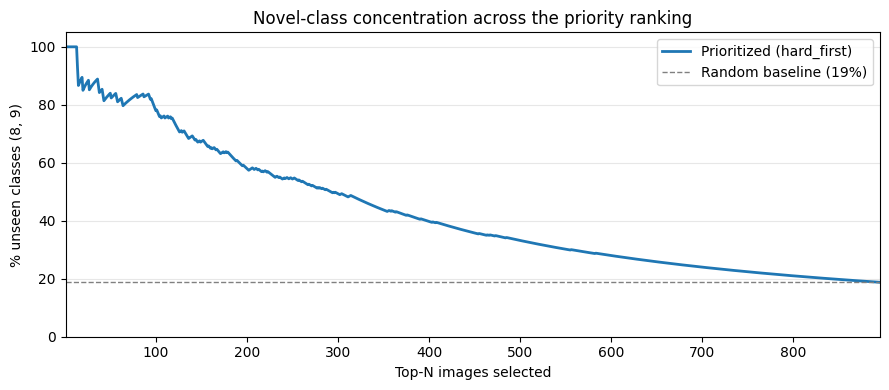

In [15]:
# Cumulative unseen-class rate as we walk down the priority ranking
all_labels = [int(test_hf[idx]["label"]) for idx in top_indices]
cumulative_unseen = np.cumsum([1 if label >= 8 else 0 for label in all_labels])
n_items = np.arange(1, len(cumulative_unseen) + 1)
unseen_pct = 100.0 * cumulative_unseen / n_items

# Baseline: what you'd get by picking images at random
total_unseen = int(cumulative_unseen[-1])
baseline_pct = 100.0 * total_unseen / len(all_labels)

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(n_items, unseen_pct, linewidth=2, label="Prioritized (hard_first)")
    ax.axhline(baseline_pct, color="gray", linestyle="--", linewidth=1, label=f"Random baseline ({baseline_pct:.0f}%)")
    ax.set_xlabel("Top-N images selected")
    ax.set_ylabel("% unseen classes (8, 9)")
    ax.set_title("Novel-class concentration across the priority ranking")
    ax.set_xlim(1, len(all_labels))
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Fallback: text summary
    for n in [50, 100, 200, 500, len(all_labels)]:
        print(f"Top {n:4d}: {unseen_pct[n - 1]:.0f}% unseen")

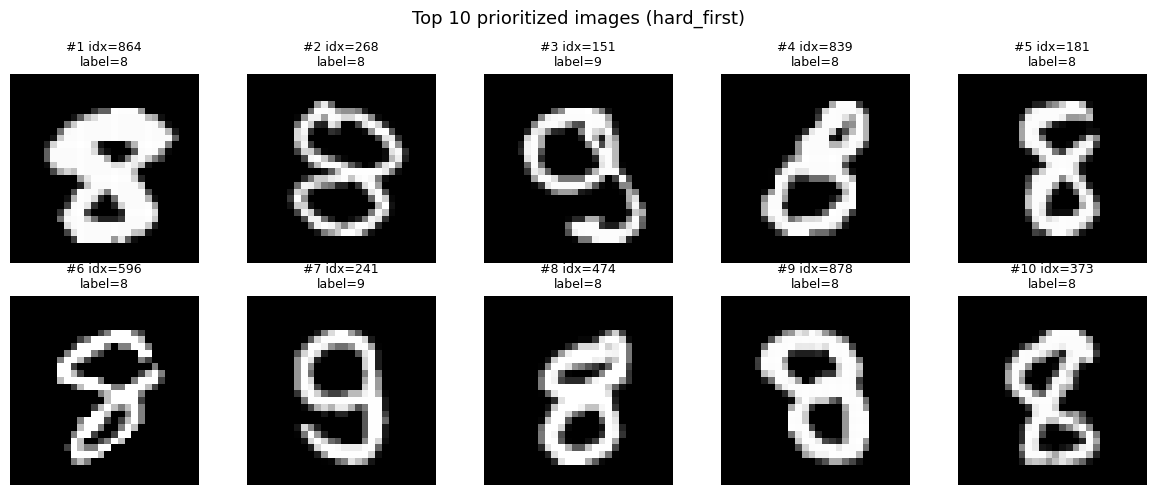

In [16]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        idx = top_indices[i]
        img = test_hf[idx]["image"]
        label = test_hf[idx]["label"]
        ax.imshow(img, cmap="gray")
        ax.set_title(f"#{i + 1} idx={idx}\nlabel={label}", fontsize=9)
        ax.axis("off")
    fig.suptitle("Top 10 prioritized images (hard_first)", fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install matplotlib to visualize: pip install matplotlib")